# 01 — Data Exploration & Feature Engineering

This notebook explores the 2025 NFL play-by-play data and validates the QB feature engineering pipeline.

**Goals:**
- Understand the shape and quality of our data
- Visualize distributions of key passing metrics
- Build and inspect the QB feature matrix
- Sanity-check metrics against known QB archetypes

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Load the Data

In [2]:
df = pd.read_parquet('../data/processed/pass_plays_qualified.parquet')
print(f'Shape: {df.shape}')
print(f'QBs: {df.passer_player_name.nunique()}')
print(f'Weeks: {sorted(df.week.unique()) if "week" in df.columns else "N/A"}')
df.head()

Shape: (16335, 42)
QBs: 38
Weeks: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18)]


,game_id,play_id,season,week,game_date,home_team,away_team,posteam,defteam,passer_player_id,passer_player_name,receiver_player_id,receiver_player_name,down,ydstogo,yardline_100,shotgun,no_huddle,qb_dropback,qb_scramble,pass_location,air_yards,yards_after_catch,pass_length,complete_pass,incomplete_pass,interception,yards_gained,touchdown,sack,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,qtr,score_differential,ep,epa,wp,wpa,cpoe,qb_epa,was_pressure
0,2025_01_ARI_NO,243.000,2025,1,2025-09-07,NO,ARI,NO,ARI,00-0039376,S.Rattler,00-0037545,R.Shaheed,2.000,7.000,74.000,1.000,0.000,1.000,0.000,middle,2.000,NaN,short,0.000,1.000,0.000,0.000,0.000,0.000,655.000,1555.000,3355.000,1.000,0.000,1.191,-0.789,0.602,-0.025,-83.418,-0.789,True
1,2025_01_ARI_NO,266.000,2025,1,2025-09-07,NO,ARI,NO,ARI,00-0039376,S.Rattler,None,None,3.000,7.000,74.000,1.000,0.000,1.000,0.000,right,14.000,NaN,short,0.000,1.000,0.000,0.000,0.000,0.000,651.000,1551.000,3351.000,1.000,0.000,0.402,-1.546,0.577,-0.028,NaN,-1.546,True
2,2025_01_ARI_NO,695.000,2025,1,2025-09-07,NO,ARI,NO,ARI,00-0039376,S.Rattler,00-0036040,J.Johnson,1.000,10.000,75.000,1.000,0.000,1.000,0.000,right,5.000,6.000,short,1.000,0.000,0.000,11.000,0.000,0.000,296.000,1196.000,2996.000,1.000,-3.000,1.688,0.677,0.511,0.030,19.414,0.677,False
3,2025_01_ARI_NO,742.000,2025,1,2025-09-07,NO,ARI,NO,ARI,00-0039376,S.Rattler,00-0037239,C.Olave,2.000,8.000,62.000,1.000,1.000,1.000,0.000,left,13.000,0.000,short,1.000,0.000,0.000,13.000,0.000,0.000,254.000,1154.000,2954.000,1.000,-3.000,1.807,1.358,0.524,0.029,32.565,1.358,False
4,2025_01_ARI_NO,1017.000,2025,1,2025-09-07,NO,ARI,NO,ARI,00-0039376,S.Rattler,00-0031236,B.Cooks,2.000,9.000,37.000,1.000,1.000,1.000,0.000,left,3.000,9.000,short,1.000,0.000,0.000,12.000,0.000,0.000,11.000,911.000,2711.000,1.000,-3.000,3.179,1.371,0.595,0.032,19.284,1.371,False


In [3]:
# Check for missing values in key columns
key_cols = ['air_yards', 'epa', 'complete_pass', 'sack', 'was_pressure',
            'score_differential', 'qb_scramble', 'pass_location']
df[key_cols].isna().sum().sort_values(ascending=False)

air_yards             1092
pass_location         1092
epa                      0
complete_pass            0
sack                     0
was_pressure             0
score_differential       0
qb_scramble              0
dtype: int64

## 2. Play-Level Distributions

Let's get a feel for the data before aggregating to the QB level.

In [4]:
# Attempts per QB
attempts = df.groupby('passer_player_name').size().sort_values(ascending=False).reset_index()
attempts.columns = ['QB', 'Attempts']

fig = px.bar(attempts, x='QB', y='Attempts',
             title='Pass Attempts by QB — 2025 Regular Season',
             color='Attempts', color_continuous_scale='blues')
fig.update_layout(xaxis_tickangle=-45, width=1000, height=500)
fig.show()

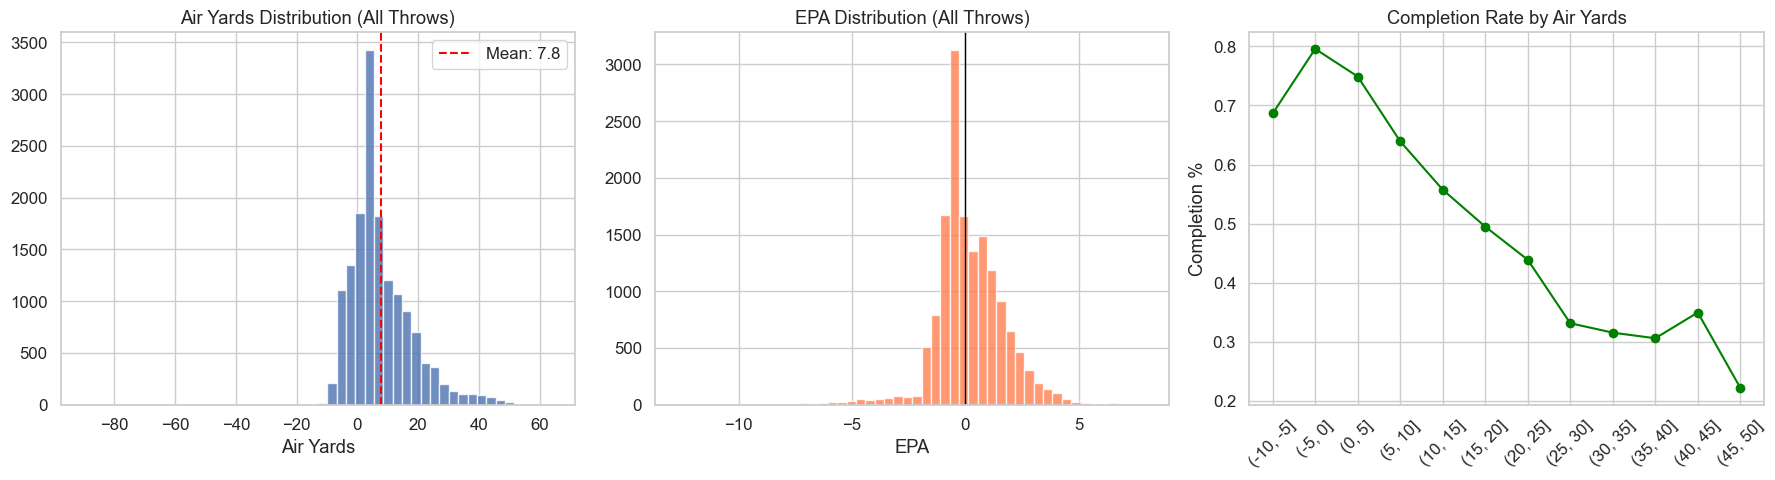

In [5]:
# Air yards distribution
throws = df[df['sack'] == 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall air yards
axes[0].hist(throws['air_yards'].dropna(), bins=50, edgecolor='white', alpha=0.8)
axes[0].set_title('Air Yards Distribution (All Throws)')
axes[0].set_xlabel('Air Yards')
axes[0].axvline(throws['air_yards'].mean(), color='red', linestyle='--', label=f'Mean: {throws["air_yards"].mean():.1f}')
axes[0].legend()

# EPA distribution
axes[1].hist(throws['epa'].dropna(), bins=50, edgecolor='white', alpha=0.8, color='coral')
axes[1].set_title('EPA Distribution (All Throws)')
axes[1].set_xlabel('EPA')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)

# Completion rate by air yards
throws['air_yards_bin'] = pd.cut(throws['air_yards'], bins=range(-10, 55, 5))
comp_by_depth = throws.groupby('air_yards_bin')['complete_pass'].mean()
axes[2].plot(range(len(comp_by_depth)), comp_by_depth.values, marker='o', color='green')
axes[2].set_xticks(range(len(comp_by_depth)))
axes[2].set_xticklabels([str(x) for x in comp_by_depth.index], rotation=45)
axes[2].set_title('Completion Rate by Air Yards')
axes[2].set_ylabel('Completion %')

plt.tight_layout()
plt.show()

In [6]:
# Pressure rate and its effect on EPA
pressure_avail = df['was_pressure'].notna().mean()
print(f'Pressure data available for {pressure_avail:.1%} of plays')

if pressure_avail > 0.5:
    pressure_effect = df[df['sack'] == 0].groupby('was_pressure')['epa'].mean()
    print(f'\nEPA clean pocket:    {pressure_effect.get(0, float("nan")):.3f}')
    print(f'EPA under pressure:  {pressure_effect.get(1, float("nan")):.3f}')
    print(f'Pressure penalty:    {pressure_effect.get(1, 0) - pressure_effect.get(0, 0):.3f} EPA/play')

Pressure data available for 100.0% of plays

EPA clean pocket:    0.273
EPA under pressure:  -0.146
Pressure penalty:    -0.420 EPA/play


## 3. Build the QB Feature Matrix

Now let's run our feature engineering pipeline and inspect the results.

In [7]:
import sys
sys.path.insert(0, '..')

from src.features.build_features import build_qb_features, get_clustering_features

features = build_qb_features(df)
print(f'Feature matrix: {features.shape}')
features.head(10)

Feature matrix: (38, 21)


,player_name,team,pass_attempts,avg_air_yards,deep_ball_rate,avg_intended_epa,epa_clean,epa_pressure,completion_pct_pressure,pressure_resilience,sack_rate,scramble_rate,clutch_epa,clutch_completion_pct,clutch_play_share,scramble_rate_mobility,scramble_yards_per_attempt,comp_pct_short,comp_pct_medium,comp_pct_deep,overall_comp_pct
passer_player_id,,,,,,,,,,,,,,,,,,,,,
00-0023459,A.Rodgers,PIT,525,6.069,0.091,0.027,0.228,-0.351,0.349,-0.579,0.055,0.000,-0.019,0.597,0.128,0.000,0.000,0.738,0.458,0.326,0.659
00-0026158,J.Flacco,CIN,430,7.398,0.109,-0.119,0.177,-0.550,0.420,-0.727,0.042,0.000,-0.130,0.514,0.172,0.000,0.000,0.692,0.451,0.316,0.609
00-0026498,M.Stafford,LA,617,9.138,0.146,0.229,0.408,-0.027,0.492,-0.435,0.037,0.000,0.261,0.620,0.175,0.000,0.000,0.733,0.553,0.410,0.653
00-0029604,K.Cousins,ATL,279,7.026,0.090,-0.016,0.099,-0.001,0.481,-0.100,0.047,0.000,0.239,0.509,0.190,0.000,0.000,0.729,0.464,0.136,0.624
00-0030565,G.Smith,LV,501,6.195,0.088,-0.147,0.257,-0.538,0.468,-0.794,0.110,0.000,0.473,0.786,0.056,0.000,0.000,0.759,0.456,0.342,0.677
00-0032268,M.Mariota,WAS,241,10.196,0.166,-0.004,0.282,-0.416,0.347,-0.698,0.066,0.000,0.005,0.500,0.133,0.000,0.000,0.714,0.613,0.297,0.618
00-0033077,D.Prescott,DAL,628,8.060,0.105,0.162,0.357,-0.043,0.572,-0.400,0.049,0.000,0.245,0.632,0.139,0.000,0.000,0.750,0.521,0.467,0.677
00-0033106,J.Goff,DET,614,6.453,0.064,0.174,0.453,-0.090,0.456,-0.543,0.062,0.000,-0.032,0.527,0.090,0.000,0.000,0.718,0.628,0.387,0.682
00-0033119,J.Brissett,ARI,527,7.638,0.087,-0.010,0.245,-0.041,0.470,-0.287,0.082,0.000,-0.168,0.527,0.104,0.000,0.000,0.727,0.520,0.325,0.651


In [8]:
# Full feature summary
features.describe().round(3)

,pass_attempts,avg_air_yards,deep_ball_rate,avg_intended_epa,epa_clean,epa_pressure,completion_pct_pressure,pressure_resilience,sack_rate,scramble_rate,clutch_epa,clutch_completion_pct,clutch_play_share,scramble_rate_mobility,scramble_yards_per_attempt,comp_pct_short,comp_pct_medium,comp_pct_deep,overall_comp_pct
count,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000
mean,429.868,7.792,0.108,0.025,0.252,-0.151,0.462,-0.403,0.069,0.000,0.004,0.567,0.135,0.000,0.000,0.722,0.531,0.352,0.647
std,139.674,0.958,0.024,0.135,0.141,0.180,0.064,0.224,0.023,0.000,0.303,0.083,0.039,0.000,0.000,0.038,0.070,0.099,0.037
min,203.000,5.859,0.049,-0.299,-0.127,-0.550,0.345,-0.858,0.035,0.000,-0.984,0.333,0.044,0.000,0.000,0.632,0.394,0.136,0.566
25%,290.500,7.228,0.090,-0.027,0.179,-0.253,0.423,-0.521,0.052,0.000,-0.132,0.517,0.112,0.000,0.000,0.692,0.469,0.302,0.619
50%,451.000,7.875,0.110,0.021,0.258,-0.161,0.465,-0.413,0.065,0.000,0.011,0.578,0.140,0.000,0.000,0.729,0.532,0.333,0.650
75%,537.750,8.354,0.123,0.125,0.340,-0.031,0.507,-0.261,0.088,0.000,0.188,0.617,0.166,0.000,0.000,0.748,0.573,0.400,0.680
max,633.000,10.196,0.166,0.296,0.549,0.235,0.572,0.217,0.118,0.000,0.569,0.786,0.194,0.000,0.000,0.806,0.680,0.615,0.720


In [9]:
# Top 10 QBs by key metrics
print('=== Most Aggressive (Avg Air Yards) ===')
print(features.nlargest(10, 'avg_air_yards')[['player_name', 'team', 'avg_air_yards', 'deep_ball_rate']].to_string(index=False))

print('\n=== Most Accurate (Completion %) ===')
print(features.nlargest(10, 'overall_comp_pct')[['player_name', 'team', 'overall_comp_pct', 'avg_air_yards']].to_string(index=False))

print('\n=== Best Under Pressure (Pressure Resilience) ===')
print(features.nlargest(10, 'pressure_resilience')[['player_name', 'team', 'pressure_resilience', 'epa_pressure']].to_string(index=False))

print('\n=== Most Clutch (Clutch EPA) ===')
print(features.nlargest(10, 'clutch_epa')[['player_name', 'team', 'clutch_epa', 'clutch_completion_pct']].to_string(index=False))

=== Most Aggressive (Avg Air Yards) ===
player_name team  avg_air_yards  deep_ball_rate
  M.Mariota  WAS         10.196           0.166
 M.Stafford   LA          9.138           0.146
     D.Maye   NE          9.132           0.130
    J.Hurts  PHI          9.009           0.134
     J.Love   GB          8.838           0.135
  L.Jackson  BAL          8.827           0.122
 J.McCarthy  MIN          8.815           0.130
 T.Lawrence  JAX          8.754           0.125
 C.Williams  CHI          8.657           0.139
   T.Shough   NO          8.361           0.110

=== Most Accurate (Completion %) ===
 player_name team  overall_comp_pct  avg_air_yards
      D.Maye   NE             0.720          9.132
     M.Jones   SF             0.703          7.427
     J.Allen  BUF             0.695          7.318
     B.Purdy   SF             0.694          7.599
   S.Rattler   NO             0.685          7.992
     D.Jones  IND             0.683          8.047
   S.Darnold  SEA             0.683  

## 4. Feature Correlations

Check which features move together and which capture independent dimensions of play style.

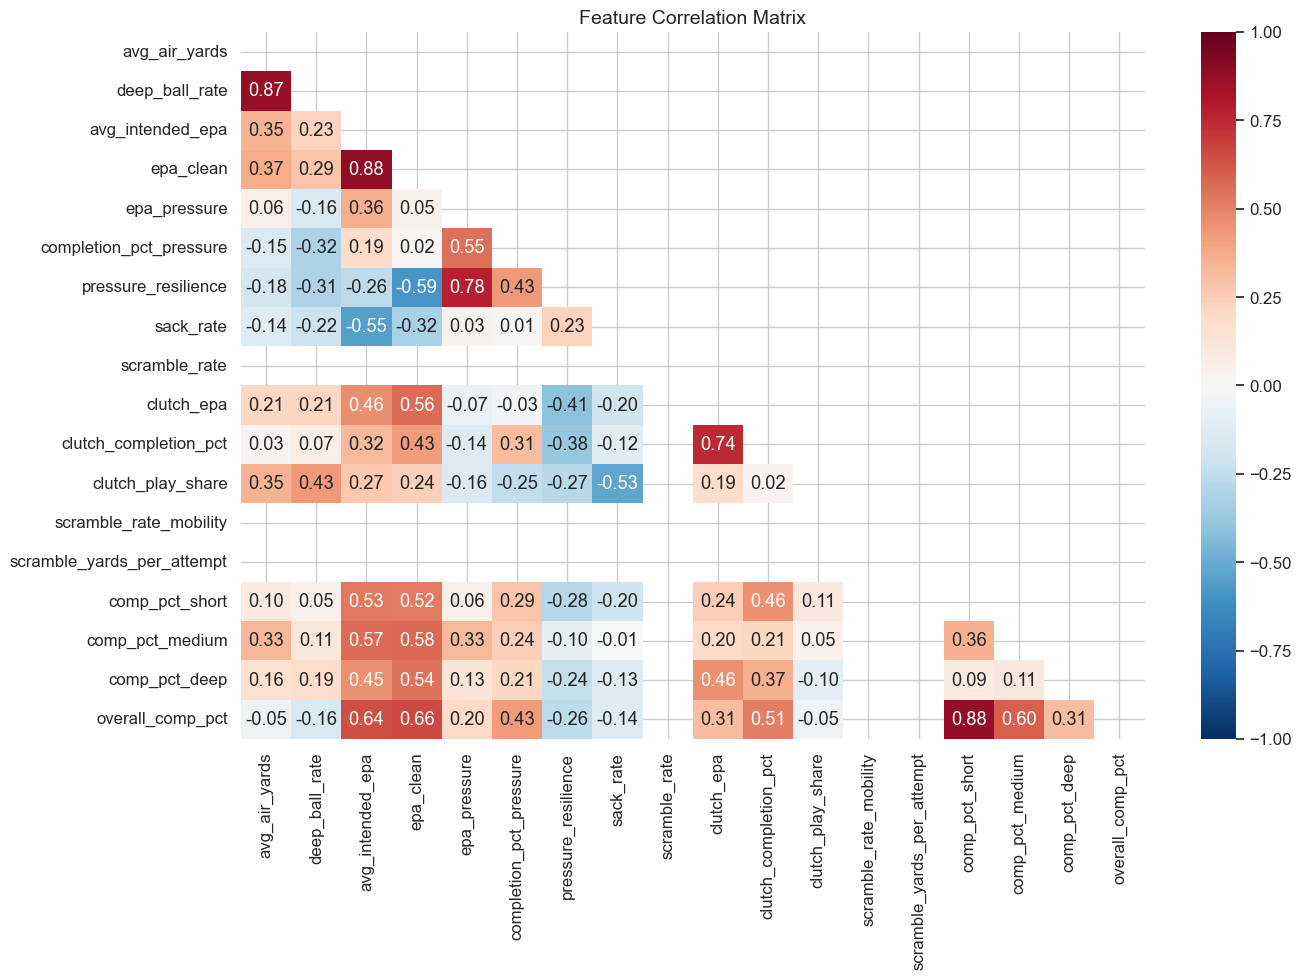

In [10]:
X_scaled, feature_cols = get_clustering_features(features)

fig, ax = plt.subplots(figsize=(14, 10))
corr = features[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Scatter Plot Previews

Some quick 2D views to build intuition before clustering.

In [11]:
plot_df = features.reset_index()

fig = px.scatter(plot_df, x='avg_air_yards', y='overall_comp_pct',
                 text='player_name', size='pass_attempts',
                 color='avg_intended_epa',
                 color_continuous_scale='RdYlGn',
                 title='Aggression vs Accuracy (sized by attempts, colored by EPA)',
                 hover_data=['team'])
fig.update_traces(textposition='top center', textfont_size=8)
fig.update_layout(width=900, height=650)
fig.show()

In [12]:
fig = px.scatter(plot_df, x='scramble_rate_mobility', y='avg_air_yards',
                 text='player_name', size='pass_attempts',
                 color='clutch_epa',
                 color_continuous_scale='RdYlGn',
                 title='Mobility vs Aggression (colored by Clutch EPA)',
                 hover_data=['team'])
fig.update_traces(textposition='top center', textfont_size=8)
fig.update_layout(width=900, height=650)
fig.show()

## 6. Quick Radar Chart Preview

Compare a couple of QBs to make sure the radar chart visualization works.

In [13]:
from src.visualization.plots import plot_radar_comparison

# Find player IDs for a couple of interesting comparisons
name_to_id = features['player_name'].reset_index().set_index('player_name')['passer_player_id'].to_dict()

# Pick two QBs with contrasting styles — adjust if these aren't in your data
qb_pairs = [
    ('P.Mahomes', 'J.Goff'),
    ('L.Jackson', 'T.Tagovailoa'),
    ('J.Allen', 'B.Purdy'),
]

for qb1_name, qb2_name in qb_pairs:
    qb1_id = name_to_id.get(qb1_name)
    qb2_id = name_to_id.get(qb2_name)
    if qb1_id and qb2_id:
        fig = plot_radar_comparison(features, [qb1_id, qb2_id])
        fig.show()
        break  # Show one for now
    else:
        print(f'{qb1_name} or {qb2_name} not found, trying next pair...')

## 7. Save Feature Matrix

Save the engineered features for use in clustering and modeling notebooks.

In [14]:
features.to_parquet('../data/processed/qb_features.parquet')
print(f'Saved QB feature matrix: {features.shape}')
print('\nReady for clustering in notebook 02!')

Saved QB feature matrix: (38, 21)

Ready for clustering in notebook 02!


---

## Key Takeaways

*Fill this in after running the notebook:*

- How many QBs qualified?
- Which metrics show the most separation between QBs?
- Any surprising findings in the scatter plots?
- Which features are highly correlated (and might be redundant for clustering)?